<a href="https://colab.research.google.com/github/simon-mellergaard/GAI-with-LLMs/blob/main/Project%20codes/Assignment05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5

> With point of departure in Chapter 6 in Hands-on Generative AI with Transformers and Diffusion Models, carefully fine-tune mistralai/Mistral-7B-v0.3 while manipulating key hyperparameters. For your best model, present the training-validation plot and completions for the prompts below:

``` python
prompts = [
    """What is the capital of Germany? Explain why thats the case and if it \
    was different in the past?""",
    "Write a Python function to calculate the factorial of a number.",
    """A rectangular garden has a length of 25 feet and a width of 15 feet. \
    If you want to build a fence around the entire garden, how many feet of \
    fencing will you need?""",
    """What is the difference between a fruit and a vegetable? Give examples \
    of each.""",
]
```

## Setup

In [1]:
# Installing pacakges
!pip install -q trl bitsandbytes
!pip install -q -U flash-attn --no-build-isolation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 12.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 35.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [1]:
# Libraries
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt

# Functions
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
# from trl import SFTConfig, SFTTrainer
from datasets import load_dataset
from google.colab import userdata
from huggingface_hub import login as login_hf
from wandb import login as login_wandb
from peft import LoraConfig
from transformers import AutoTokenizer
from transformers import pipeline

In [2]:
# Libraries
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt

# Functions
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from trl import SFTConfig, SFTTrainer
from datasets import load_dataset
from google.colab import userdata
from huggingface_hub import login as login_hf
from wandb import login as login_wandb
from peft import LoraConfig
from transformers import AutoTokenizer
from transformers import pipeline

In [2]:
# Logging in to Hugging Face and wandb
os.environ['HF_TOKEN'] = userdata.get('HF')
os.environ['WANDB_TOKEN'] = userdata.get('wandb')
HF_USER = userdata.get('HF_USER')
login_hf(os.environ['HF_TOKEN'])
login_wandb(key = os.environ['WANDB_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: simonmellergaard (simonmellergaard-aarhus-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
# Setting up the device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"

## Finetuning mistral with adapters

The model used is the [Mistral-7B model](https://huggingface.co/mistralai/Mistral-7B-v0.3), which has more than 7 billion parameters. In order to fine-tune such a large model, QLoRA is used, which only fine-tunes the adapters, while also using quantization. This makes it possible to fine-tune the model.

When loading the model, the bitsAndBytesConfig function is used to apply quantizatino to the model, which reduce the size of the model significantly. Double quantization is used, and it is quantized to 4 bits. Furthermore, the normalized 4-bit quantization, as this is usually a good setting as weights tend to be normalized in Neural networks. During training, 16-precision is used.

### Flash attention
Flash-attention is a feature that can furthermore be used in the model to speed of the training process. However, it is only supported on certain hardware. The below function tests whether Flash attention is available on a T4 GPU.

In [ ]:
# Checks if flash-attention is supported.
def supports_flash_attention(device_id):
    """Check if a GPU supports FlashAttention."""
    major, minor = torch.cuda.get_device_capability(device_id)

    # Check if the GPU architecture is Ampere (SM 8.x) or newer (SM 9.0)
    is_sm8x = major == 8 and minor >= 0
    is_sm90 = major == 9 and minor == 0

    return is_sm8x or is_sm90
supports_flash_attention(device)

False

Flash attention is unfortunately not available for the T4 GPU, and the analysis therefore continues without it. The quanization and model loading is done in the followign code:

In [4]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-v0.3",
    quantization_config=quantization_config,
    device_map="auto",
    # attn_implementation="flash_attention_2" # Flash attention to train faster
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

The [Dataset](https://huggingface.co/datasets/timdettmers/openassistant-guanaco) is loaded, and the peft config is set up. This is a subset of the Open Assistant dataset, which contains high quality conversations between a human user and the Open Assistant AI.

The parameter efficient fine-tuning is done using LoRA (low-rank adaptation). The parameters are set to r=8 and alpha=16 initially, where setting alpha=2*r is the default. Using peft allows to fine-tune a very large model, that would otherwise be unfeasable to fine-tune.

In [6]:
dataset = load_dataset("timdettmers/openassistant-guanaco", split="train")
dataset_eval = load_dataset("timdettmers/openassistant-guanaco", split="test")

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    task_type="CAUSAL_LM",
)

Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.


The training arguments are specified below. SFTconfig is used to optimize the model for text generation. Training arguments the learning rate, epochs. The batch size is reduced to fit the model to memory.

The model is trained on 300 items from the training set, and evaluated on 100 items on the test set.

In [ ]:
sft_config = SFTConfig(
    "mistral-finetuned",
    push_to_hub=True,
    per_device_train_batch_size=4, # Small batch size
    weight_decay=0.07,             # Reduced from 0.1
    lr_scheduler_type="cosine",
    learning_rate=2e-4,            # Reduced from 5e-4
    num_train_epochs=2,
    # eval_strategy="epoch",
    eval_strategy="steps",
    eval_steps=40,
    logging_steps=40,
    gradient_checkpointing=True,
    max_length=512,
    dataset_text_field="text",
    packing=True,
)

trainer = SFTTrainer(
    model,
    args=sft_config,
    train_dataset=dataset.select(range(725)), # Increased from 300
    eval_dataset=dataset_eval.select(range(100)),
    peft_config=peft_config,
)

/usr/local/lib/python3.11/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/725 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/725 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/725 [00:00<?, ? examples/s]

The model is ready to be trained and pushed to the hub:

In [ ]:
trainer.train()
trainer.push_to_hub()

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
40,1.195000,1.077960,1.153933,81267.000000,0.724993
80,1.150000,1.058754,1.097016,161939.000000,0.730586
120,1.093800,1.055437,1.101212,242568.000000,0.730796
160,1.015000,1.056794,1.063525,322611.000000,0.729492
200,1.073800,1.058304,1.066705,402906.000000,0.729550
240,1.074600,1.058050,1.070161,484169.000000,0.730000


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/simon-mellergaard/mistral-finetuned/commit/fe25a998446bdc34be600b2aa5ee2ee7883843fd', commit_message='End of training', commit_description='', oid='fe25a998446bdc34be600b2aa5ee2ee7883843fd', pr_url=None, repo_url=RepoUrl('https://huggingface.co/simon-mellergaard/mistral-finetuned', endpoint='https://huggingface.co', repo_type='model', repo_id='simon-mellergaard/mistral-finetuned'), pr_revision=None, pr_num=None)

In the modelling process, different training parameters have been modified. This includes the learning rate, which has been reduced to ensure the model learns. The training dataset has also been increased to provide more data the model can learn from.

The training results shows the training loss, validation loss, entropy and mean token accuracy......

## Plotting the training loss

In [ ]:
def plot_loss(trainer, title='Training and Validation Loss over Epochs'):
    # Creating dataframe for plotting. Load pandas and matplotlib
    history = trainer.state.log_history[:-1]
    results = pd.DataFrame(columns=pd.DataFrame(history).columns)
    # The results are stored in alternating order in the results, so it is
    # iterated through every second instance
    for i in range(len(history)):
        if i % 2 == 0:
            new_row = pd.DataFrame(history[i], index=[0])
            results = pd.concat([results, new_row], ignore_index=True)
        else:
            # The bottom most row is inserted the specific columns
            results.loc[len(results) - 1, history[i].keys()] = history[i]
    # Plotting the results
    plt.figure(figsize=(7, 5))
    plt.plot(results['epoch'], results['loss'], marker='o', label='Training Loss', color = 'blue')
    plt.plot(results['epoch'], results['eval_loss'], marker='o', label='Validation Loss', color = 'orange')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

/tmp/ipykernel_63/80527297.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


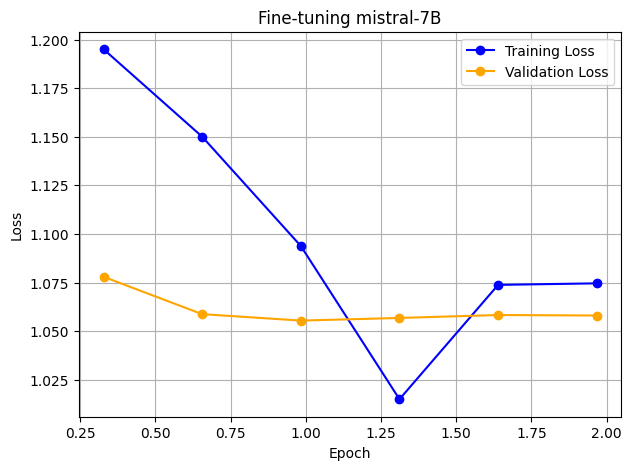

In [ ]:
plot_loss(trainer, 'Fine-tuning mistral-7B')

## Loading the model and adapter

The adapter moel is loaded by first loading the model, and then loading the adapter on top of it.

In [4]:
# Loading the base model
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.3")
model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-v0.3",
    dtype=torch.float16,
    device_map=device,
)

# Loading the fine-tuned adapter.
model.load_adapter(f"{HF_USER}/mistral-finetuned")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/780 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

A pipeline is used to test the 4 different queries.

In [6]:
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

Device set to use cuda


The text wrapper function belows makes the output formatted more nicely.

In [11]:
# Function taken from the NLP repository to wrap text.
# Source: https://github.com/nlp-with-transformers/notebooks/blob/main/utils.py
from textwrap import TextWrapper
def wrap_print_text(print):
    def wrapped_func(text):
        if not isinstance(text, str):
            text = str(text)
        wrapper = TextWrapper(
            width=80,
            break_long_words=True,
            break_on_hyphens=False,
            replace_whitespace=False,
        )
        return print("\n".join(wrapper.fill(line) for line in text.split("\n")))
    return wrapped_func
print = wrap_print_text(print)

To automate the process, a function is created to input the prompt and the context of the query. This is set up in the same way as the training data is set up.

In [8]:
def generate_text(prompt):
    return pipe(f"### Human: {prompt}### Assistant:", max_new_tokens=100)[0]['generated_text']

In [18]:
torch.manual_seed(42) # For reproducibility
q1 = generate_text("""What is the capital of Germany? Explain why thats the case and \
if it was different in the past?""")
q2 = generate_text("Write a Python function to calculate the factorial of a number.")
q3 = generate_text("""A rectangular garden has a length of 25 feet and a width \
of 15 feet. If you want to build a fence around the entire garden, how many \
feet of fencing will you need?""")
q4 = generate_text("""What is the difference between a fruit and a vegetable? \
Give examples of each.""")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Printing the output:

In [19]:
print(q1)
print('\n' + '='*80 + '\n')
print(q2)
print('\n' + '='*80 + '\n')
print(q3)
print('\n' + '='*80 + '\n')
print(q4)

### Human: What is the capital of Germany? Explain why thats the case and if it
was different in the past?### Assistant: The capital of Germany is Berlin.
However, the capital of Germany was not always Berlin. Before World War II, the
capital was the city of Bonn. After the reunification of Germany, the capital
was moved back to Berlin.

Bonn was the capital of West Germany from 1949 to 1990, and the capital of East
Germany was East Berlin. After the reunification of Germany on October 3, 1990,
Bonn and


### Human: Write a Python function to calculate the factorial of a number.###
Assistant: Here is an example function in Python that calculates the factorial
of a number:

def factorial(number):
    fact = 1
    while number > 1:
        fact *= number
        number -= 1
    return fact

To use this function, you would call it with the number whose factorial you want
to calculate, like this:

print(factorial(5)) # prints 120


### Human: A rectangular garden has a length of 25 feet an

The output looks more or less decent. Especially the math problem is difficult for the model. The model has correct output for the difference between fruits and vegetables, as well as correctly identifying the capital of Germany before Berlin. The python function is tested in the code cell below:

In [19]:
def factorial(number):
    fact = 1
    while number > 1:
        fact *= number
        number -= 1
    return fact

print(factorial(5))

120


The code also seem to be working as it should. The function does not handle negative numbers, but the prompt specified to make a simple function.